In [1]:
def load_namespace():
    import sys
    sys.path.insert(1,f'/wsu/home/gy/gy40/gy4065/hm_jetscapeml_source')#WSU Grid
    sys.path.insert(1,'/content/drive/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v1
    sys.path.insert(1,'/content/drive/MyDrive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v2
    sys.path.insert(1,f'/mnt/g/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#wsl gdrive
    sys.path.insert(1,'G:\\My Drive\\Projects\\110_JetscapeMl\\hm_jetscapeml_source') #Windows GDrive
    sys.path.insert(1,'/home/arsalan/Projects/110_JetscapeML/hm_jetscapeml_source/') #office tower
    sys.path.insert(1,'/home/arsalan/wsu-grid/hm_jetscapeml_source') #WSU Grid fssh
    
    
load_namespace()

In [2]:
# Loading/Preparing Environment for simulation
from jet_ml.config import Config
#sim main
folds=1
epochs=50
dataset_size=1200000 #10800000 
# dataset_size=1800000 

#sim test
# folds=2
# epochs=2
# # dataset_size=250
# dataset_size=1000

classification_parameter="eloss"
q0_value=2.0
constant_parameter=f"q0_{q0_value}"

model_name="vgg16_net"

constant_parameter=None
if constant_parameter!=None:
    model_name=f"{model_name}_{constant_parameter}"

batch_size=128
server_name=f"batch_{batch_size}_"

cancel_rl_on_plateau=True
if cancel_rl_on_plateau==True:
    server_name=f"{server_name}no_rl_"

srv_hm3="hm_srv3_cpu_24_mem_32gb"
srv_a100="wsu_grid_a100_cpu_8_mem_150gb"
srv_v100="wsu_grid_v100_cpu_24_mem_256gb"
server_name=f"{server_name}{srv_hm3}"
# server_name=f"wsu_grid_v100_cpu_24_mem_256gb_batch_{batch_size}"
simulation_name=f"{classification_parameter}_{model_name}_{folds}_fold_{epochs}_epoch_{int(dataset_size/1000)}k_dataset_size_{server_name}"

config=Config(simulation_name=simulation_name)
config.__str__()

2024-11-13 15:59:50.568429: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-13 15:59:50.575751: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-13 15:59:50.584667: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-13 15:59:50.587423: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-13 15:59:50.594003: I tensorflow/core/platform/cpu_feature_guar

Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/models/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.


2024-11-13 15:59:51.637303: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


'Project Root: /home/arsalan/wsu-grid/hm_jetscapeml_source\nData Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/data\nModels Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models\nReports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports\nFigures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures\nSimulation Models Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nSimulation Reports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nSimulation Figures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nEnvironment Details:\n  TensorFlow Version: 2.17.0\n  Keras Version: 3.5.0\n  Python Version: 3.12.5 | packaged by conda-for

In [3]:
#loading training history from csv file
import pandas as pd
# Load the CSV file into a DataFrame
history_df = pd.read_csv('~/wsu-grid/hm_jetscapeml_data/all_simulations/simulation-results-deep-model-cnn-01-1200K-config-01-epoch-50/hm_jetscape_ml_model_history.csv')

# Display the first few rows of the data
print(history_df.head())

# Convert the DataFrame to a dictionary format similar to history.history
history_dict = history_df.to_dict(orient='list')


         loss  accuracy    val_loss  val_accuracy        lr
0  194.013473  0.518175  138.563553      0.523925  0.000005
1   93.398660  0.555462   56.871259      0.573117  0.000005
2   36.799384  0.578148   22.578955      0.605263  0.000005
3   15.461756  0.621190   10.443005      0.680854  0.000005
4    8.232039  0.727313    6.898879      0.735675  0.000005


In [4]:
class MockHistory:
    def __init__(self, history):
        self.history = history

# Create a mock history object
history = MockHistory(history_dict)

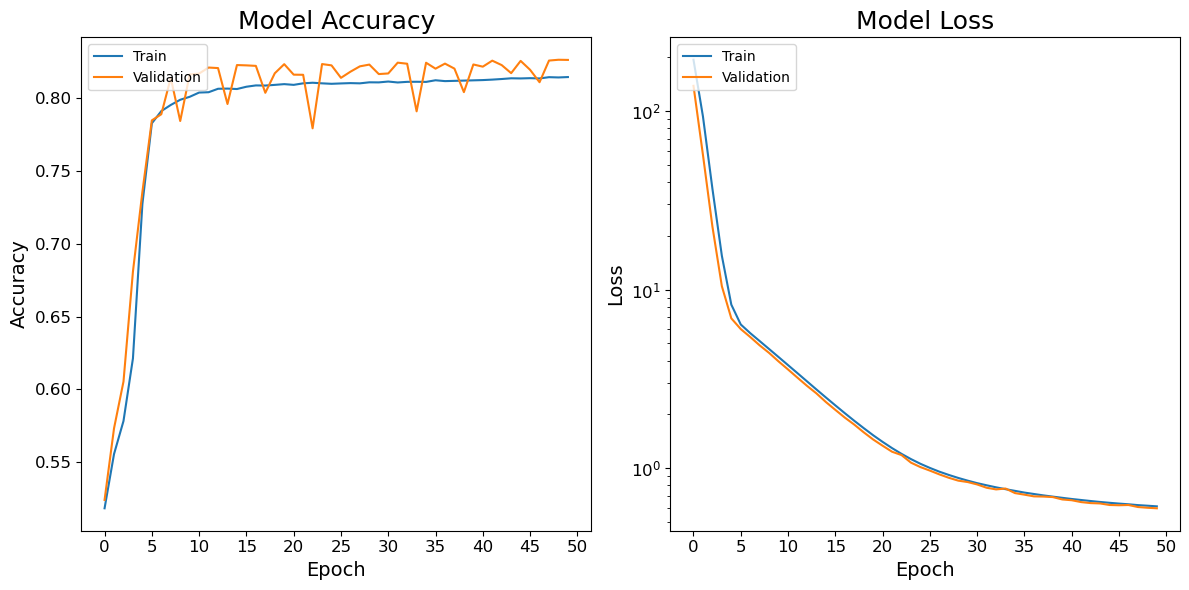

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss.png'

In [5]:
from jet_ml.evaluation import plot_training_history
plot_training_history(history=history,fold=None,loss_y_scale='log')

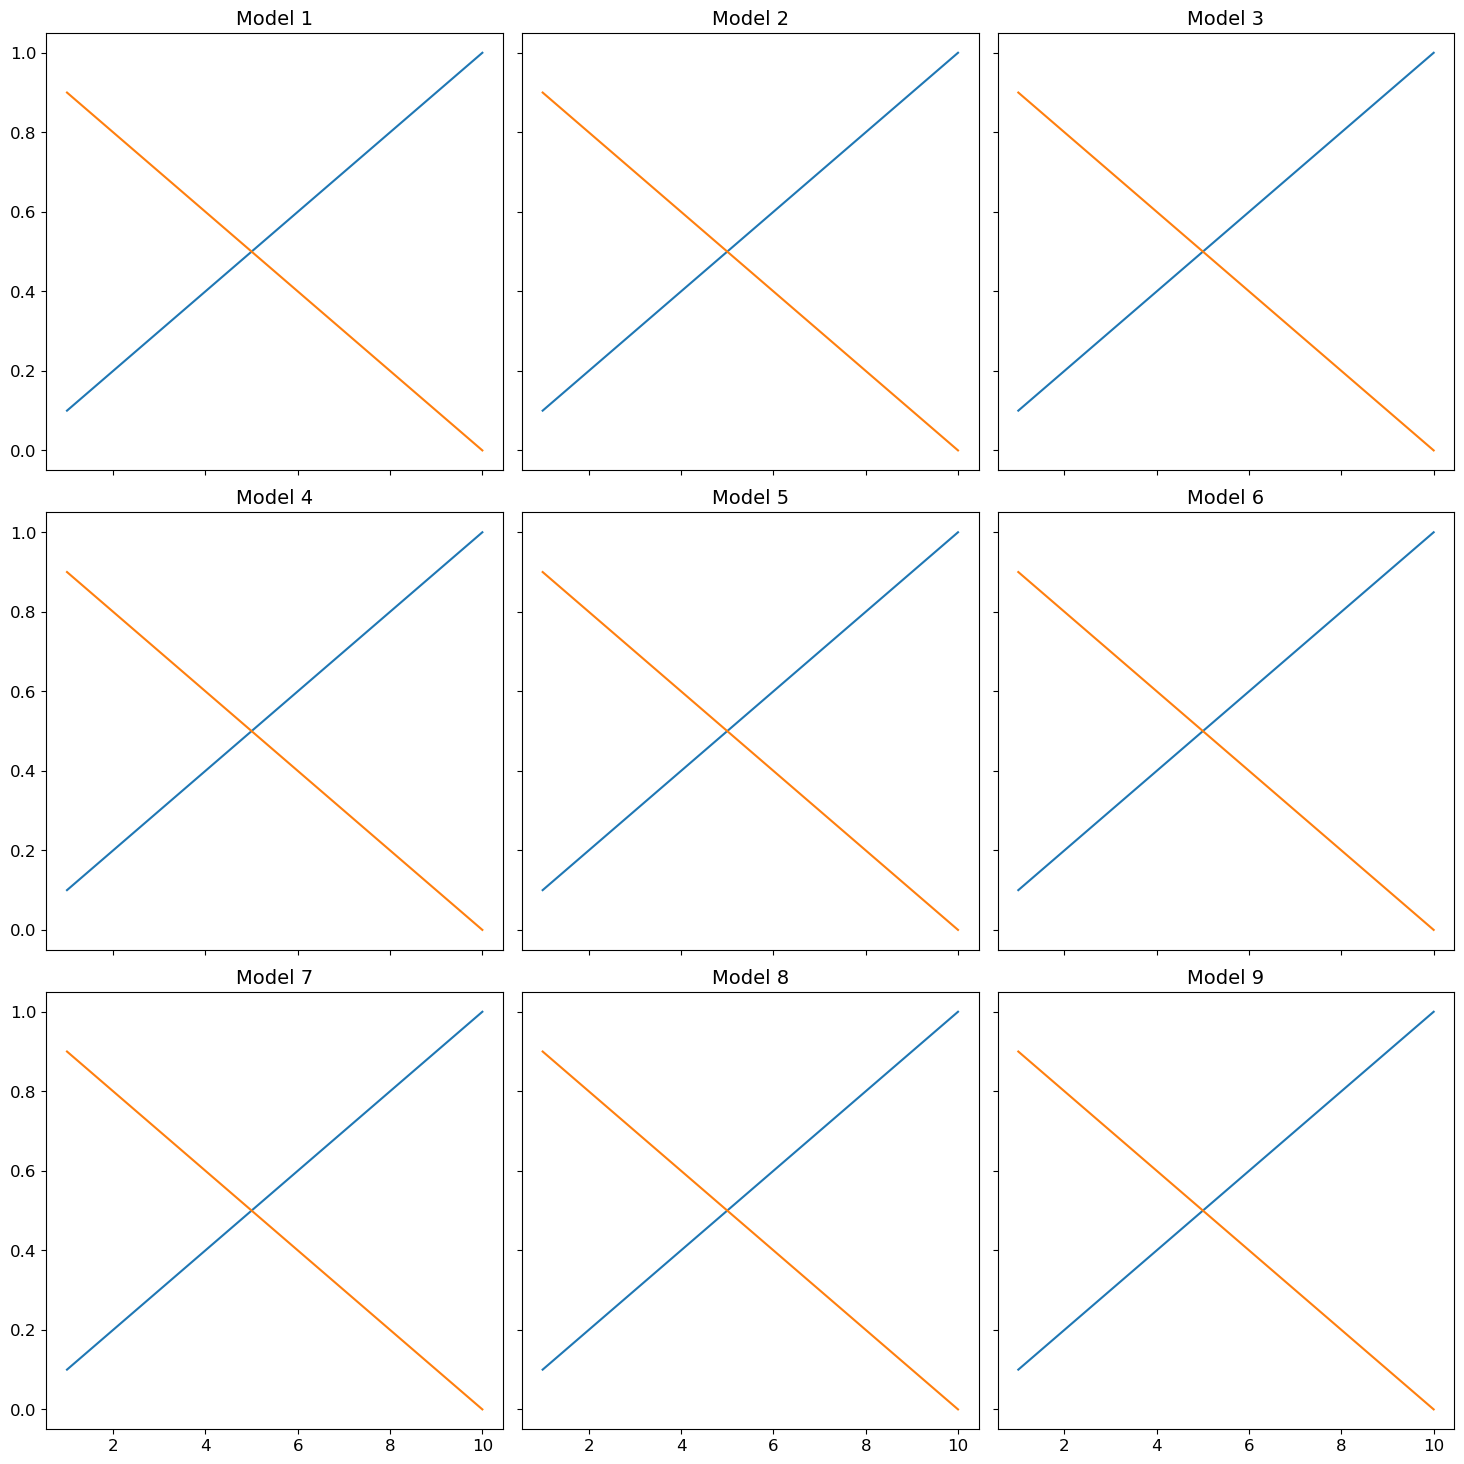

In [6]:
import matplotlib.pyplot as plt

# Sample data for illustration (replace with your data)
epochs = range(1, 11)
acc_data = [0.1 * i for i in epochs]
loss_data = [1 - 0.1 * i for i in epochs]

# Create a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust figsize to control overall size

# Increase font size for readability
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.plot(epochs, acc_data, label='Accuracy')
        ax.plot(epochs, loss_data, label='Loss')
        ax.set_title(f'Model {i*3 + j + 1}')
        
        # Hide x and y axis labels for inner plots to reduce clutter
        if i < 2:  # Hide x labels except for bottom row
            ax.set_xticklabels([])
        if j > 0:  # Hide y labels except for first column
            ax.set_yticklabels([])

        # Optionally adjust the aspect ratio to make it fit better
        ax.set_aspect('auto')

# Use tight_layout with padding adjustments to fill space
plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)  # Adjust padding as needed

plt.show()

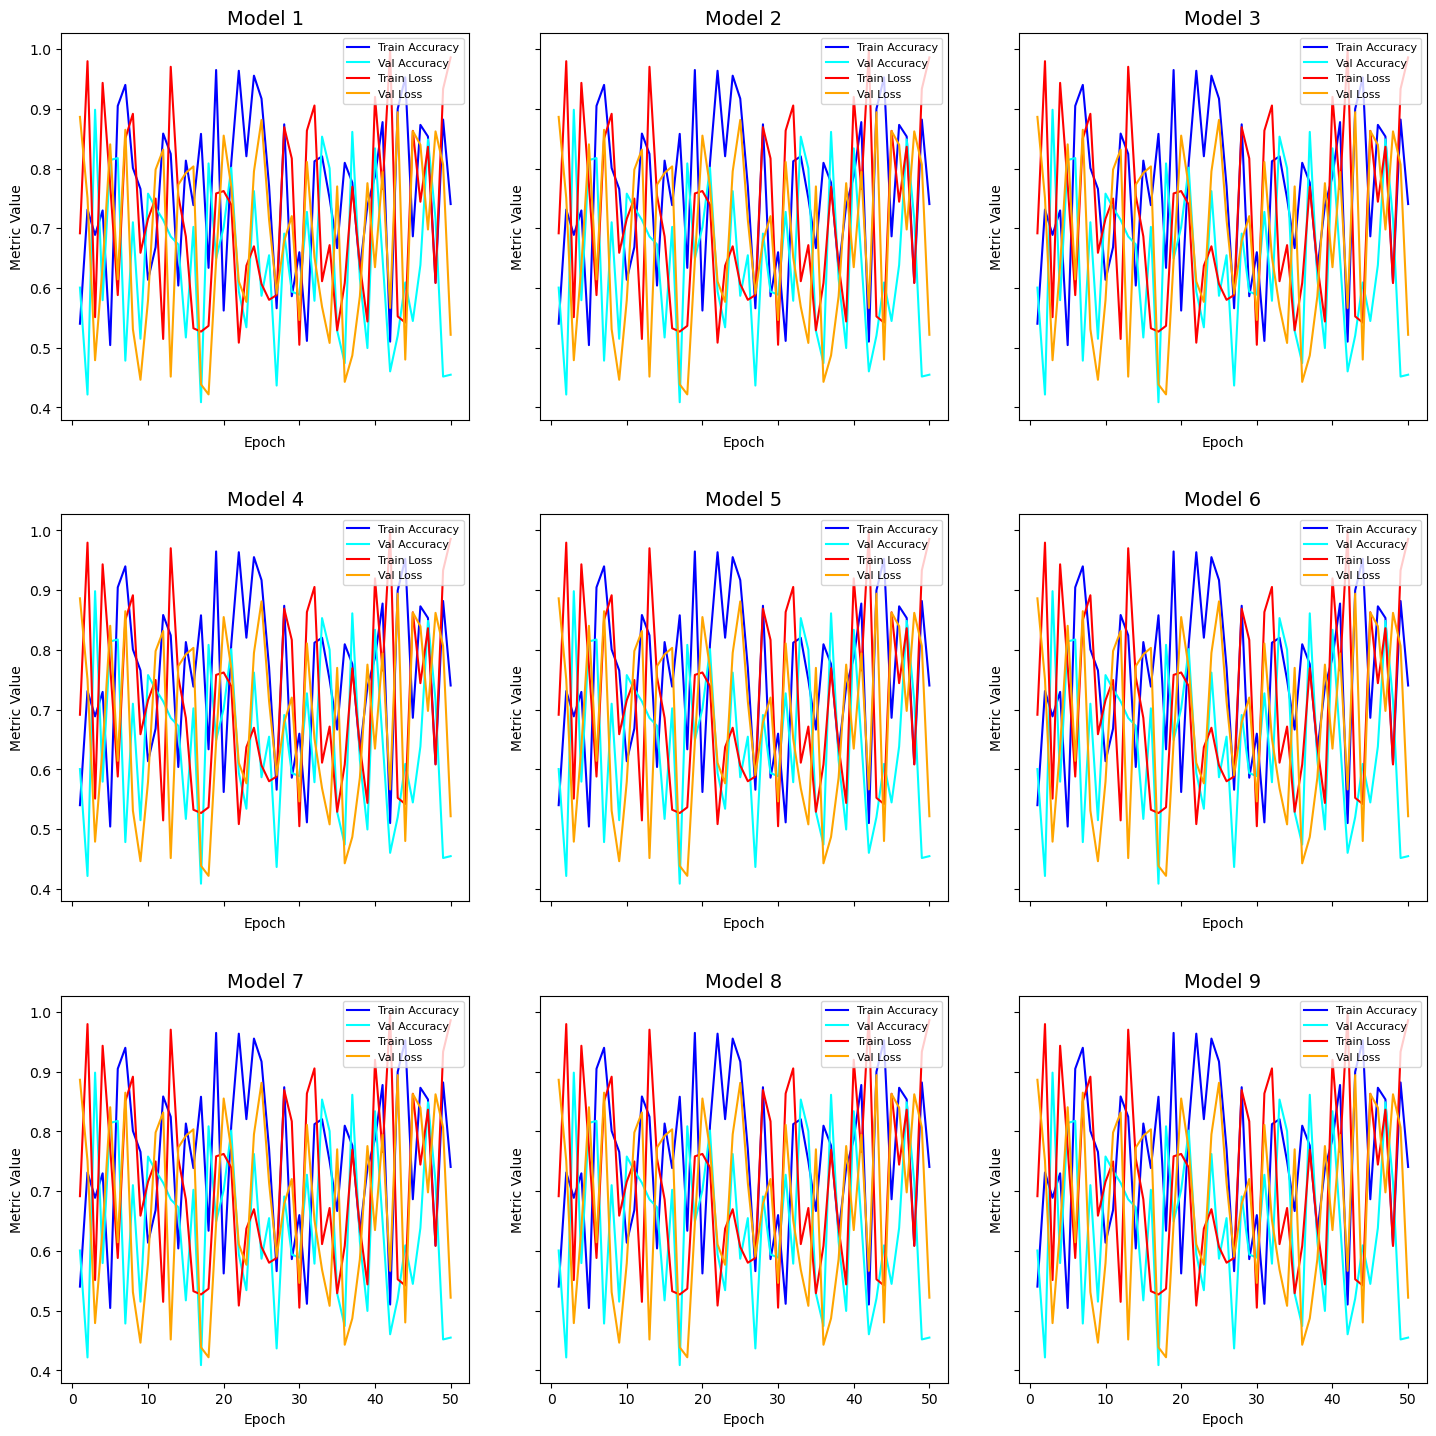

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for illustration (replace with your actual data)
epochs = np.arange(1, 51)
acc_data = np.random.uniform(0.5, 1.0, size=50)  # Example accuracy data
val_acc_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation accuracy data
loss_data = np.random.uniform(0.5, 1.0, size=50)  # Example loss data
val_loss_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation loss data

# Create a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust figsize as needed

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        
        # Plot accuracy and validation accuracy
        ax.plot(epochs, acc_data, label='Train Accuracy', color='blue')
        ax.plot(epochs, val_acc_data, label='Val Accuracy', color='cyan')
        
        # Plot loss and validation loss
        ax.plot(epochs, loss_data, label='Train Loss', color='red')
        ax.plot(epochs, val_loss_data, label='Val Loss', color='orange')
        
        # Set titles and labels
        ax.set_title(f'Model {i*3 + j + 1}', fontsize=14)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Metric Value', fontsize=10)
        
        # Add a legend for clarity
        ax.legend(loc='upper right', fontsize=8)
        
        # Optionally, remove x and y labels for inner plots to reduce clutter
        if i < 2:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

# Adjust layout to fill the entire figure
plt.tight_layout(pad=3.0)

plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Sample data for illustration (replace with your actual data)
epochs = np.arange(1, 51)
acc_data = np.random.uniform(0.5, 1.0, size=50)  # Example accuracy data
val_acc_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation accuracy data
loss_data = np.random.uniform(0.5, 1.0, size=50)  # Example loss data
val_loss_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation loss data

# Create a 3x3 grid of subplots, with each cell containing two stacked plots for accuracy and loss
fig = plt.figure(figsize=(18, 18))
outer_grid = GridSpec(3, 3, wspace=0.3, hspace=0.3)

for i in range(9):
    # Create an inner grid with 2 rows for each cell in the 3x3 outer grid
    inner_grid = GridSpec(2, 1, subplot_spec=outer_grid[i], hspace=0.15)
    
    # Accuracy plot
    ax1 = fig.add_subplot(inner_grid[0])
    ax1.plot(epochs, acc_data, label='Train Accuracy', color='blue')
    ax1.plot(epochs, val_acc_data, label='Val Accuracy', color='cyan')
    ax1.set_title(f'Model {i + 1} - Accuracy', fontsize=14)
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='upper right', fontsize=8)

    # Loss plot
    ax2 = fig.add_subplot(inner_grid[1])
    ax2.plot(epochs, loss_data, label='Train Loss', color='red')
    ax2.plot(epochs, val_loss_data, label='Val Loss', color='orange')
    ax2.set_title(f'Model {i + 1} - Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right', fontsize=8)

# Display the figure
plt.show()


TypeError: GridSpec.__init__() got an unexpected keyword argument 'subplot_spec'

<Figure size 1800x1800 with 0 Axes>

/tmp/ipykernel_140251/4158466104.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


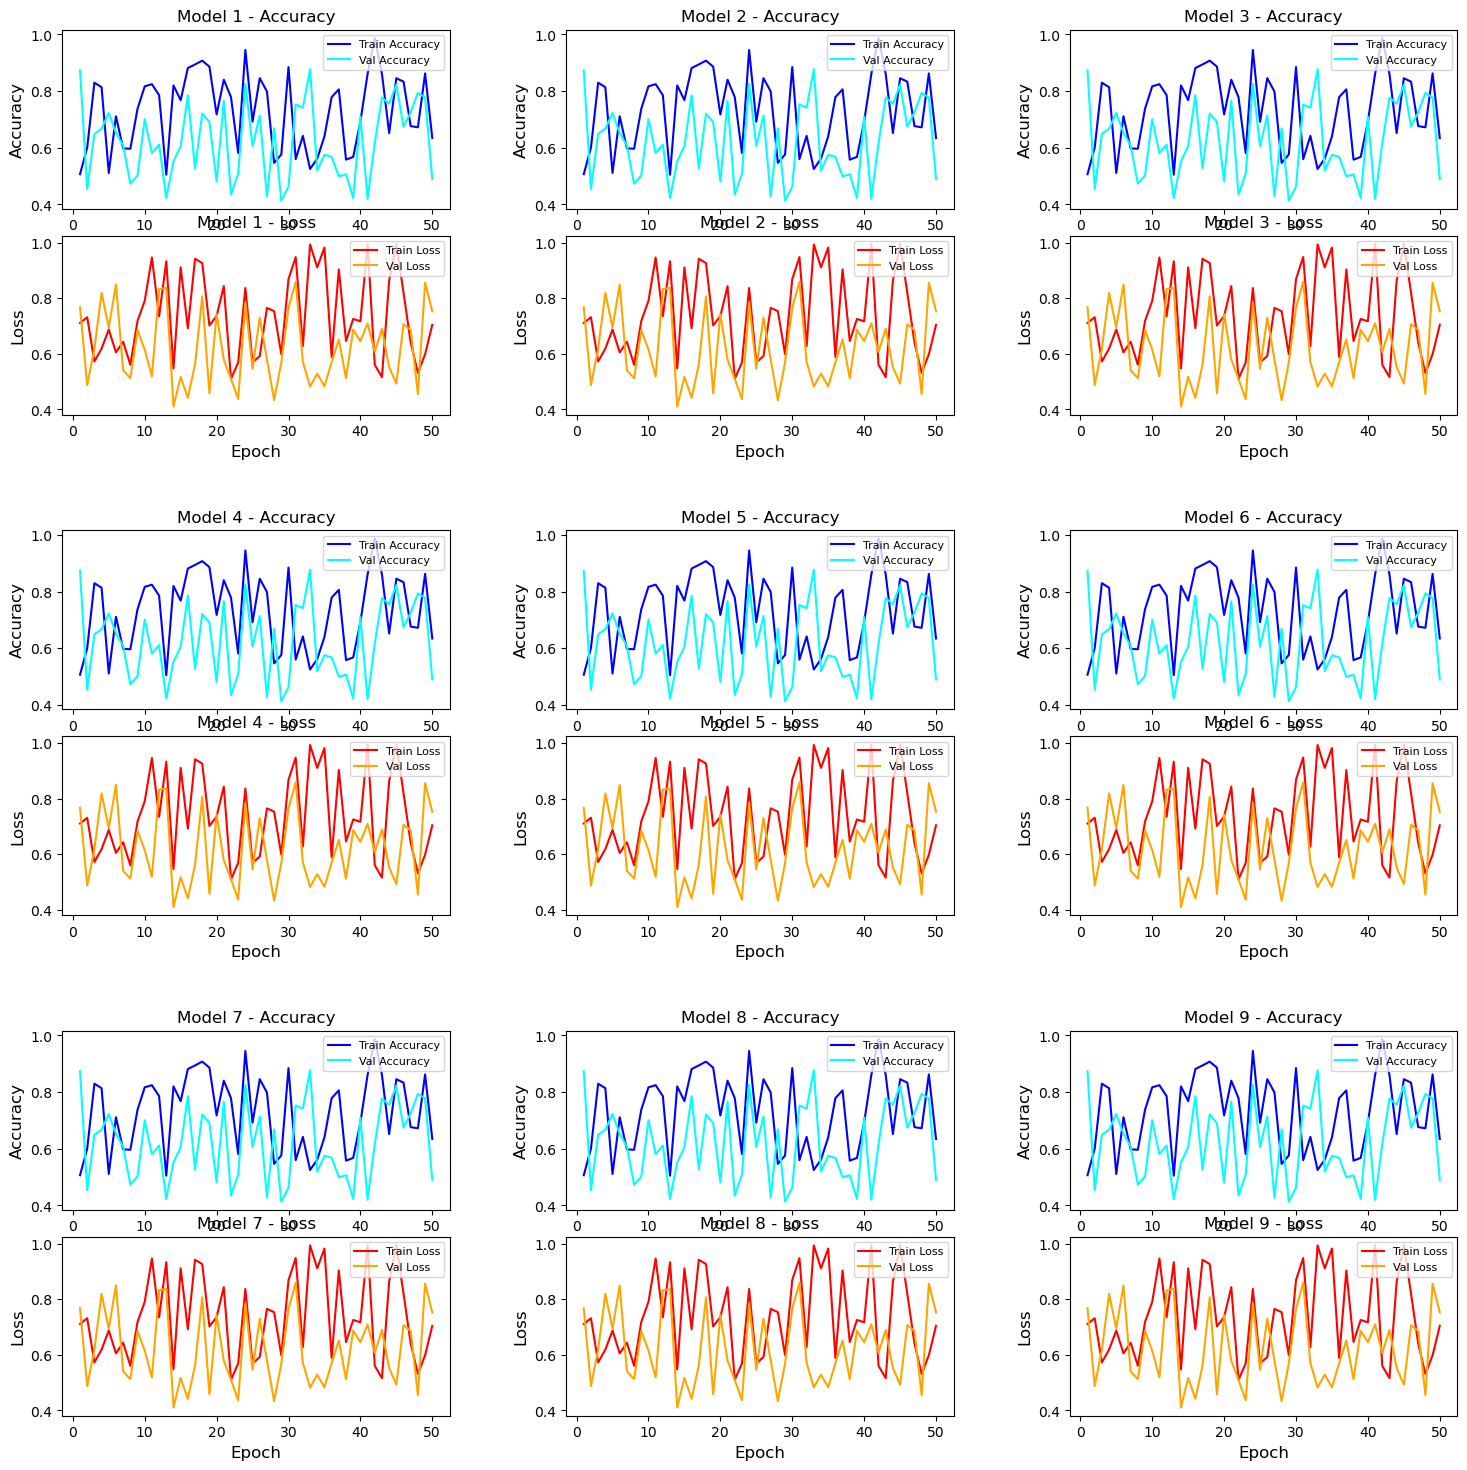

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for illustration (replace with your actual data)
epochs = np.arange(1, 51)
acc_data = np.random.uniform(0.5, 1.0, size=50)  # Example accuracy data
val_acc_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation accuracy data
loss_data = np.random.uniform(0.5, 1.0, size=50)  # Example loss data
val_loss_data = np.random.uniform(0.4, 0.9, size=50)  # Example validation loss data

# Create the outer 3x3 grid
fig = plt.figure(figsize=(18, 18))
outer_grid = fig.add_gridspec(3, 3, wspace=0.3, hspace=0.3)

for i in range(3):
    for j in range(3):
        # Create an inner 2-row grid within each outer grid cell
        inner_grid = outer_grid[i, j].subgridspec(2, 1, hspace=0.15)
        
        # Accuracy plot
        ax1 = fig.add_subplot(inner_grid[0])
        ax1.plot(epochs, acc_data, label='Train Accuracy', color='blue')
        ax1.plot(epochs, val_acc_data, label='Val Accuracy', color='cyan')
        ax1.set_title(f'Model {i*3 + j + 1} - Accuracy', fontsize=12)
        ax1.set_ylabel('Accuracy')
        ax1.legend(loc='upper right', fontsize=8)

        # Loss plot
        ax2 = fig.add_subplot(inner_grid[1])
        ax2.plot(epochs, loss_data, label='Train Loss', color='red')
        ax2.plot(epochs, val_loss_data, label='Val Loss', color='orange')
        ax2.set_title(f'Model {i*3 + j + 1} - Loss', fontsize=12)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()

# Display the figure
plt.show()
